# 02_image_analysis.ipynb chỉ tập trung phân tích ảnh X-ray của dataset IU X-Ray Dataset.

## 1. Import thư viện


In [31]:
import os
import json
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

## 2. Load đường dẫn

In [32]:
data_dir = "../../data/iu_xray"

annotation_path = os.path.join(data_dir, "annotation.json")
image_dir = os.path.join(data_dir, "images")

with open(annotation_path, "r") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['train', 'val', 'test'])


### Ví dụ ảnh+text

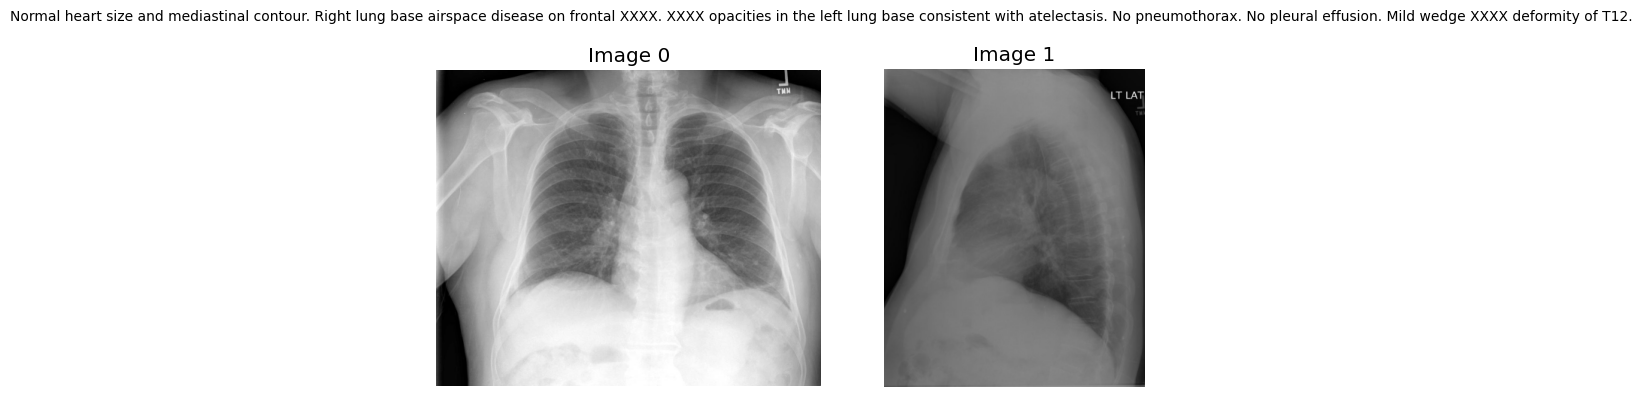

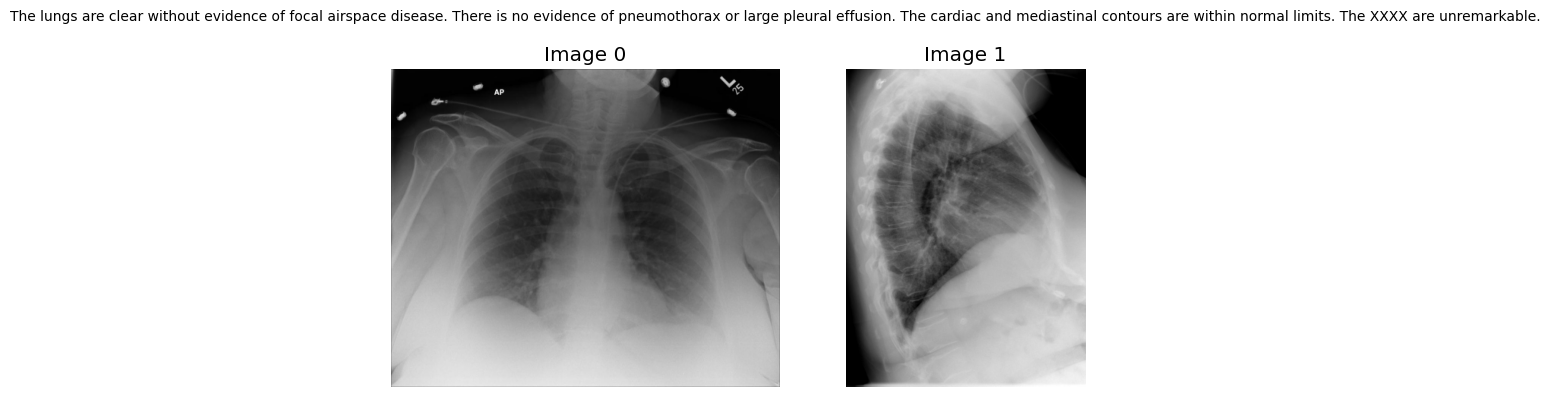

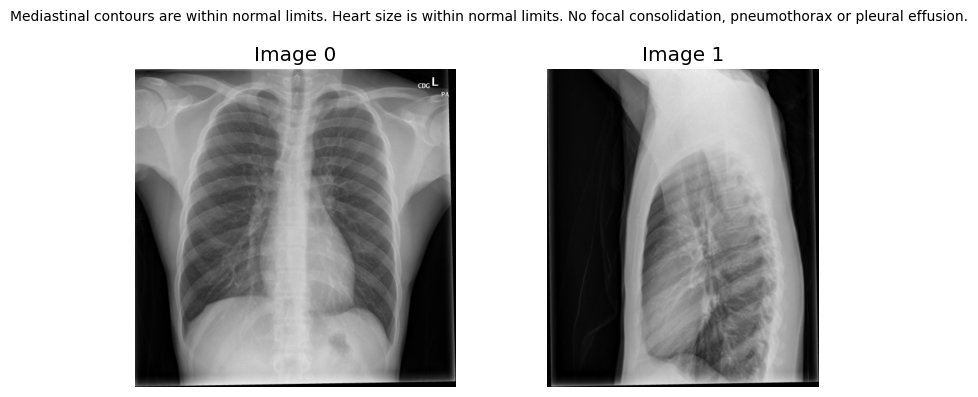

In [33]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

samples = random.sample(data["train"], 3)

for item in samples:

    imgs = item["image_path"]
    report = item["report"]

    plt.figure(figsize=(8,4))

    for i, img in enumerate(imgs):

        path = os.path.join(image_dir, img)
        image = Image.open(path)

        plt.subplot(1,2,i+1)
        plt.imshow(image, cmap="gray")
        plt.axis("off")
        plt.title(f"Image {i}")

    plt.suptitle(report, fontsize=10)
    plt.tight_layout()
    plt.show()

## 3.Convert annotation ---> json

In [34]:
records = []

for split in ["train", "val", "test"]:
    
    for item in data[split]:

        report = item["report"]
        image_paths = item["image_path"]

        for img in image_paths:

            records.append({
                "id": item["id"],
                "image": img,
                "report": report,
                "split": split
            })

df = pd.DataFrame(records)

print("Total images:", len(df))
df.head()

Total images: 5910


,id,image,report,split
0,CXR2384_IM-0942,CXR2384_IM-0942/0.png,The heart size and pulmonary vascularity appea...,train
1,CXR2384_IM-0942,CXR2384_IM-0942/1.png,The heart size and pulmonary vascularity appea...,train
2,CXR2926_IM-1328,CXR2926_IM-1328/0.png,Cardiac and mediastinal contours are within no...,train
3,CXR2926_IM-1328,CXR2926_IM-1328/1.png,Cardiac and mediastinal contours are within no...,train
4,CXR1451_IM-0291,CXR1451_IM-0291/0.png,Left lower lobe calcified granuloma. Heart siz...,train


## 4. Kiểm tra ảnh tồn tại

In [35]:
missing = []

for img in df["image"]:

    path = os.path.join(image_dir, img)

    if not os.path.exists(path):
        missing.append(img)

print("Missing images:", len(missing))

Missing images: 0


## 5. Kích thước ảnh

In [36]:
widths = []
heights = []

for img in tqdm(df["image"]):

    path = os.path.join(image_dir, img)

    try:
        image = Image.open(path)

        w, h = image.size

        widths.append(w)
        heights.append(h)

    except:
        pass

print("Min width:", min(widths))
print("Max width:", max(widths))

print("Min height:", min(heights))
print("Max height:", max(heights))

100%|██████████| 5910/5910 [00:00<00:00, 17394.54it/s]

Min width: 512
Max width: 512
Min height: 362
Max height: 873


## 6. Histogram

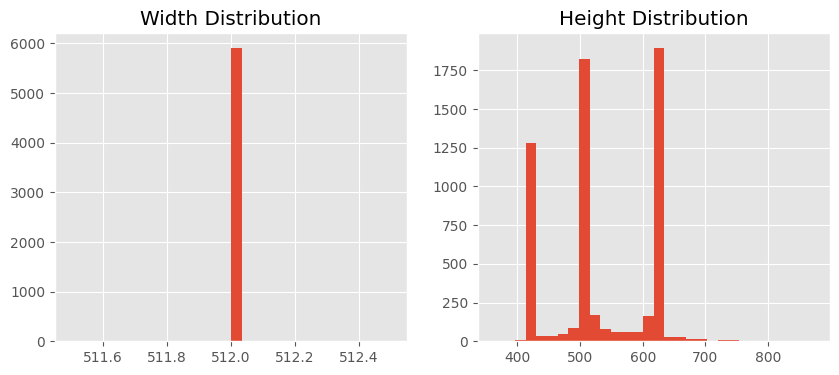

In [37]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=30)
plt.title("Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=30)
plt.title("Height Distribution")

plt.show()

## 7. Kiểm tra số kênh (RGB/Gray)

In [38]:
channels = []

for img in df["image"][:200]:

    path = os.path.join(image_dir, img)

    image = Image.open(path)
    image = np.array(image)

    if len(image.shape) == 2:
        channels.append(1)
    else:
        channels.append(image.shape[2])

print("Channels:", set(channels))

Channels: {3}


100%|██████████| 100/100 [00:01<00:00, 74.27it/s]


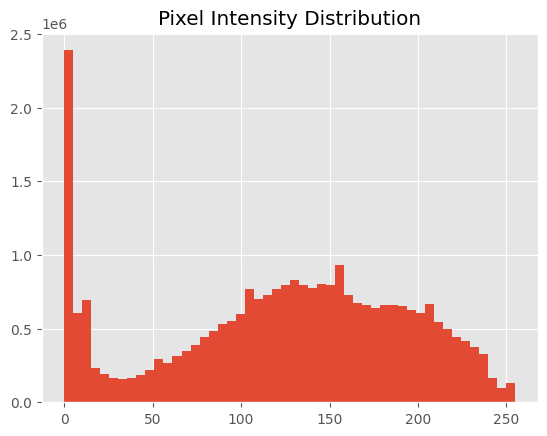

In [39]:
pixels = []

for img in tqdm(df["image"][:100]):

    path = os.path.join(image_dir, img)

    image = Image.open(path).convert("L")
    image = np.array(image)

    pixels.extend(image.flatten())

plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

## 8. Load vài ảnh ví dụ

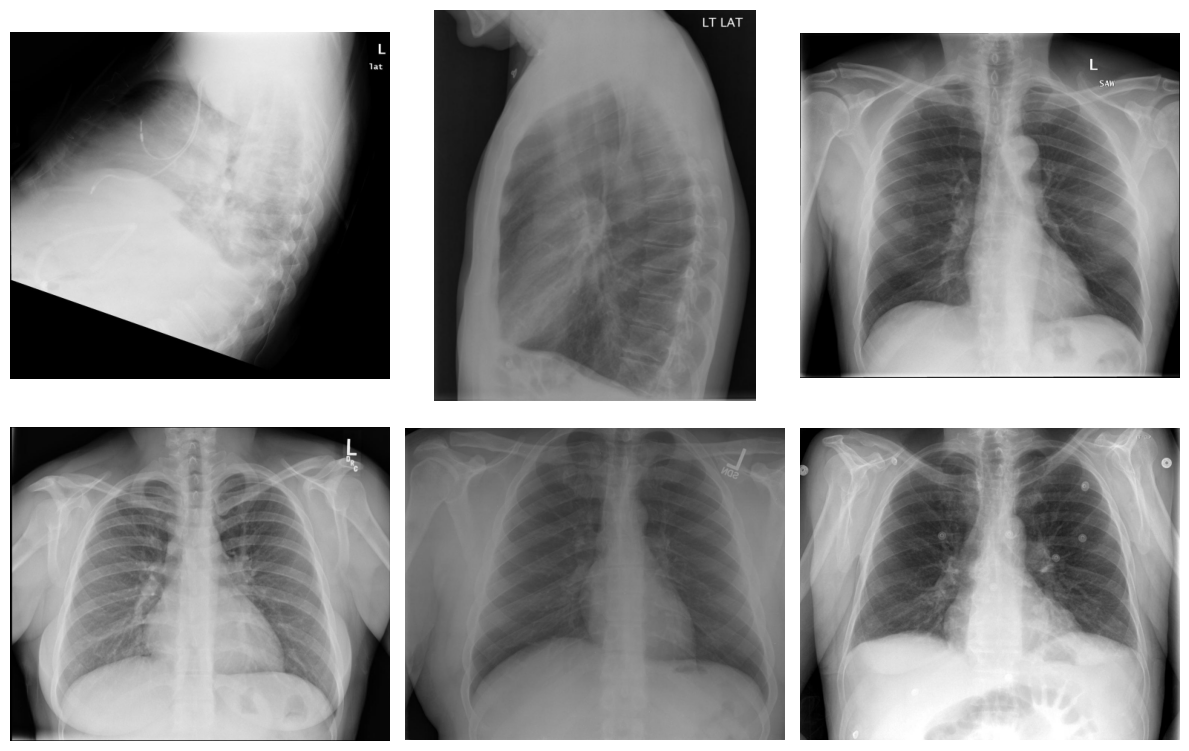

In [40]:
samples = df.sample(6)

plt.figure(figsize=(12,8))

for i, (_, row) in enumerate(samples.iterrows()):

    path = os.path.join(image_dir, row["image"])
    image = Image.open(path)

    plt.subplot(2,3,i+1)
    plt.imshow(image, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Kiểm tra số ảnh theo mỗi report

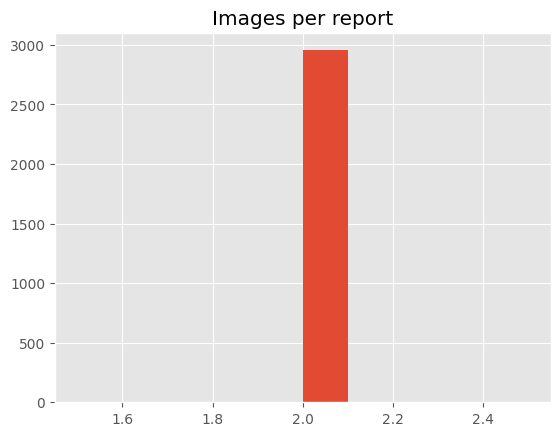

2    2955
Name: count, dtype: int64


In [41]:
image_counts = []

for split in data:
    for item in data[split]:
        image_counts.append(len(item["image_path"]))

plt.hist(image_counts)
plt.title("Images per report")
plt.show()

print(pd.Series(image_counts).value_counts())